In [2]:
import torch
from torch import nn
from torch import Tensor
from torch import optim
import torch.nn.functional as F


In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/usr/ebuild/installs/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# Device and seed setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# === Load dataset ===
data = pd.read_csv("spatial_avg_data-ERAsinglelevel_2020-24_daily.csv")

# === Extract relevant features ===
s_data = data[["asn", "rsn", "siconc"]].values

# === Train-test split ===
train_data = s_data[:5461]
test_data = s_data[5461:6050]

# === Scale features using only training stats ===
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# === Define constants for computing snow depth proxy ===
A, B = 600, 300

def compute_snow_depth_proxy(data):
    siconc_term = (data[:, 2] * A) / (A - B)
    albedo_density_term = (data[:, 0] * data[:, 1]) / (A - B)
    return (siconc_term + albedo_density_term).reshape(-1, 1)

# === Compute and normalize snow depth proxy ===
train_depth = compute_snow_depth_proxy(train_scaled)
test_depth = compute_snow_depth_proxy(test_scaled)

mean_depth, std_depth = train_depth.mean(), train_depth.std()
train_depth_norm = (train_depth - mean_depth) / std_depth
test_depth_norm = (test_depth - mean_depth) / std_depth

# === Convert to sequences ===
def create_sequences(inputs, targets, seq_len):
    X, Y = [], []
    for i in range(len(inputs) - seq_len + 1):
        X.append(inputs[i:i+seq_len])
        Y.append(targets[i:i+seq_len])  # supervision at end of sequence
    return np.array(X), np.array(Y)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(train_scaled[:, 1:2], train_depth_norm, seq_length)  # only snow density as input
X_test_seq, y_test_seq = create_sequences(test_scaled[:, 1:2], test_depth_norm, seq_length)

# === Convert to PyTorch tensors ===
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

# === Confirm shapes ===
print(f"Train X shape: {X_train_tensor.shape}, y shape: {y_train_tensor.shape}")
print(f"Test X shape: {X_test_tensor.shape}, y shape: {y_test_tensor.shape}")


Train X shape: torch.Size([5452, 10, 1]), y shape: torch.Size([5452, 10, 1])
Test X shape: torch.Size([580, 10, 1]), y shape: torch.Size([580, 10, 1])


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

#  Data Augmentation Function for Contrastive Learning
def augment_data(x, noise_std=0.01):

    noise = torch.randn_like(x) * noise_std  # Add Gaussian noise
    x_aug = x + noise
    return x_aug


import torch
import torch.nn.functional as F

def contrastive_loss(z_i, z_j, scale=0.05):

    batch_size = z_i.size(0)

    # Normalize embeddings
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)

    # Create a large similarity matrix
    similarity_matrix = torch.matmul(z_i, z_j.T) / scale

    #Create a similarity matrix that combines z_i and z_j
    combined_z = torch.cat([z_i,z_j], dim=0)
    combined_similarity = torch.matmul(combined_z, combined_z.T) / scale

    #create labels.
    labels = torch.arange(batch_size, device=z_i.device)
    combined_labels = torch.cat([labels, labels], dim=0) #correct label concatination.

    #remove diagonal.
    mask = ~torch.eye(combined_labels.shape[0], device=combined_labels.device).bool()
    combined_similarity = combined_similarity.masked_select(mask).view(combined_labels.shape[0], -1)
    #Do not repeat labels.
    #combined_labels = combined_labels.repeat(2)

    loss = F.cross_entropy(combined_similarity, combined_labels)
    return loss

# Bayesian LSTM Model with Encoder-Decoder and Contrastive Learning
class LSTMContrastive(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=1, dropout_rate=0.4):
        super(LSTMContrastive, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout_rate = dropout_rate

        # LSTM Encoder
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_rate)

        # LSTM Decoder
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_rate)

        # Fully Connected Layers
        self.fc_depth = nn.Linear(hidden_dim, output_dim)  # Predict depth
        self.fc_params = nn.Sequential(
            nn.Linear(hidden_dim, 32),  
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)  # Predicting (w, b, c)
        )
    def forward(self, x, x_aug):
        # Encode original
        encoder_out_x, (h_n_x, c_n_x) = self.encoder_lstm(x)
        decoder_out_x, _ = self.decoder_lstm(encoder_out_x, (h_n_x, c_n_x))
    
        # Encode augmented
        encoder_out_aug, (h_n_aug, c_n_aug) = self.encoder_lstm(x_aug)
        decoder_out_aug, _ = self.decoder_lstm(encoder_out_aug, (h_n_aug, c_n_aug))
    
        # Predict depth at each time step: (batch, time, 1) → (batch, time)
        depth_pred = self.fc_depth(decoder_out_x).squeeze(-1)
    
        # Predict parameters using last time step
        lstm_out_last_x = decoder_out_x[:, -1, :]  # (batch, hidden)
        params_pred = self.fc_params(lstm_out_last_x)  # (batch, 3)
        w_est_raw, b_est_raw, c_est_raw = params_pred[:, 0:1], params_pred[:, 1:2], params_pred[:, 2:3]
    
        # Apply stability constraints
        w_est = torch.sigmoid(w_est_raw) * 2.0 - 1.0  # (batch, 1)
        b_est = torch.exp(b_est_raw)                 # (batch, 1)
        c_est = torch.tanh(c_est_raw) * 10.0         # (batch, 1)

        # Compute mean snow density: assume feature index 1 or 0 = rsn
        mean_snow_density = x[:, :, 0].mean(dim=1, keepdim=True)  # (batch, 1)
    
        # Broadcast to match (batch, time_steps)
        b_est_exp = b_est.expand_as(depth_pred)
        c_est_exp = c_est.expand_as(depth_pred)
        w_est_exp = w_est.expand_as(depth_pred)
        mean_density_exp = mean_snow_density.expand_as(depth_pred)
    
        # Physics-based snow depth at each time step
        estimated_snow_depth = w_est_exp * mean_density_exp + b_est_exp * depth_pred + c_est_exp
    
        # Contrastive loss from final embeddings
        contrastive_loss_value = contrastive_loss(
            decoder_out_x[:, -1, :], decoder_out_aug[:, -1, :]
        ).mean()
    
        return depth_pred, params_pred, estimated_snow_depth, contrastive_loss_value


Let's use 2 GPUs!


/home/asampath/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/asampath/.local/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/tmp/ipykernel_1045474/4203393465.py:55: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  l1_norm = sum(p.abs().sum() for p in model.parameters())
/tmp/ipykernel_1045474/4203393465.py:60: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will 

Epoch 0/500, Loss: 6.8167
Epoch 50/500, Loss: 3.6714
Epoch 100/500, Loss: 3.4586
Epoch 150/500, Loss: 3.4065
Epoch 200/500, Loss: 3.3384
Epoch 250/500, Loss: 3.3128
Epoch 300/500, Loss: 3.2993
Epoch 350/500, Loss: 3.2772
Epoch 400/500, Loss: 3.2853
Epoch 450/500, Loss: 3.2620
(580, 10)
(580, 10)
Training results saved to training_results.pth
Data successfully written to average_depths.csv


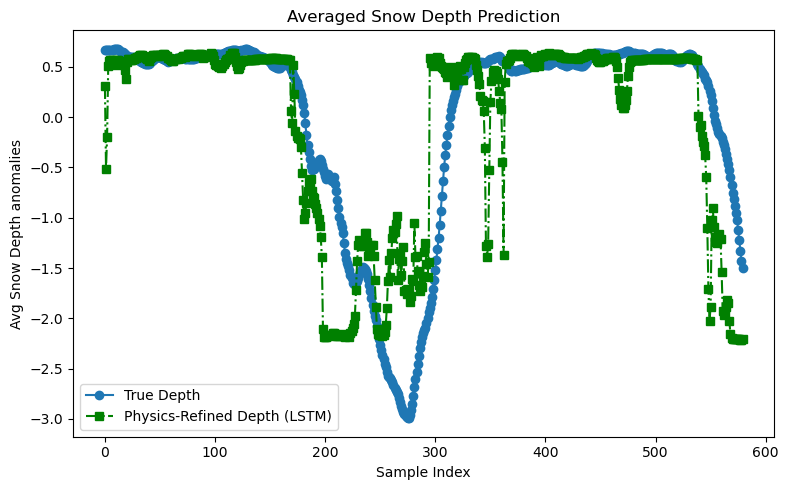

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Initialize Model & Optimizer ===
model = LSTMContrastive()  # Move model to device
criterion_depth = nn.MSELoss()  # Loss for depth prediction
criterion_estimated_snow_depth = nn.MSELoss()  # Loss for predicted
optimizer = optim.Adam(model.parameters(), lr=0.0005) # removed weight_decay from here.

# Check for multiple GPUs and wrap with DataParallel if available
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Move model to device
model = model.to(device)

# === Training Setup ===
epochs = 500
batch_size = 16

# Convert data to PyTorch datasets
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# === Store losses & predictions ===
train_losses = []

# === Training Loop ===
for epoch in range(epochs):
    total_loss = 0
    model.train()  # Set to training mode

    for batch_x, batch_y in train_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)  # move batch to device.
        optimizer.zero_grad()
        batch_x_aug = augment_data(batch_x)
        # Correct Forward Pass
        depth_pred, params_pred, estimated_snow_depth_pred, contrastive_loss_value = model(batch_x, batch_x_aug)
        loss_depth = criterion_depth(depth_pred, batch_y[:, -1, :])
        loss_estimated_snow_depth = criterion_depth(estimated_snow_depth_pred, batch_y[:, -1, :])
        contrastive_loss_value = torch.mean(contrastive_loss_value)  # Ensure scalar
        loss = loss_depth + loss_estimated_snow_depth + contrastive_loss_value

        # L1 Regularization
        l1_lambda = 0.001  # Adjust lambda as needed
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss += l1_lambda * l1_norm

        #L2 Regularization
        l2_lambda = 1e-5 #adjust lambda as needed.
        l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
        loss+= l2_lambda * l2_norm

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Store loss for visualization
    train_losses.append(total_loss / len(train_dataloader))

    #Print Progress Every 50 Epochs
    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {train_losses[-1]:.4f}")

# === After Training: Evaluate on Test Set ===
model.eval()
depth_predictions = []
estimated_depth_predictions = []
with torch.no_grad():
    for batch_x, _ in test_dataloader:
        batch_x = batch_x.to(device)
        batch_x_aug = augment_data(batch_x)  # create augmented data.
        depth_pred, params_pred, estimated_snow_depth, contrastive_loss_value = model(batch_x, batch_x_aug)  # unpack 4 values.
        depth_predictions.append(depth_pred.cpu())
        estimated_depth_predictions.append(estimated_snow_depth.cpu())

# Convert Predictions to NumPy
estimated_depth_predictions_np = torch.cat(estimated_depth_predictions).squeeze().numpy()
depth_predictions_np = torch.cat(depth_predictions).squeeze().numpy()
true_depths_np = y_test_tensor.cpu().squeeze().numpy()
print(depth_predictions_np.shape)
print(true_depths_np.shape)
avg_pred = depth_predictions_np.mean(axis=1)
avg_est = estimated_depth_predictions_np.mean(axis=1)
avg_true = true_depths_np.mean(axis=1)
# === Save Training Results ===
torch.save(
    {
        "epoch": epochs,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "depth_predictions_np": depth_predictions_np,
        "estimated_depth_predictions_np": estimated_depth_predictions_np,
        "true_depths_np": true_depths_np,
    },
    "LSTM-training_results.pth",
)
print("Training results saved to training_results.pth")

# === Write to CSV file ===
df = pd.DataFrame({
    'avg_pred': avg_pred,
    'avg_est': avg_est,
    'avg_true': avg_true
})

# Write to a CSV file
df.to_csv('LSTM-average_depths.csv', index=False)  # index=False prevents writing the row numbers to the CSV
print("Data successfully written to average_depths.csv")

# === Plot Training Loss ===
# === Plot all three in the same figure ===
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg_true)), avg_true, label="True Depth", marker='o', linestyle='-')

plt.plot(
        range(len(avg_est)),
    avg_est,
    label="Physics-Refined Depth (LSTM)",
    marker='s',
    linestyle="-.",
    color="green",
)

plt.xlabel("Sample Index")
plt.ylabel("Avg Snow Depth anomalies")
plt.title("Averaged Snow Depth Prediction")
plt.legend()
plt.tight_layout()
#plt.ylim(0, 1)  # Set y-axis limits between 0 and 1
plt.show()

In [7]:
# Arrays: shape (samples, timesteps)
# depth_predictions_np         → LSTM prediction
# estimated_depth_predictions_np → Physics-refined prediction
# true_depths_np               → Ground truth

from sklearn.metrics import mean_squared_error

# === Overall metrics (flattened)
mse_lstm = mean_squared_error(true_depths_np.flatten(), depth_predictions_np.flatten())
rmse_lstm = np.sqrt(mse_lstm)
mean_lstm = depth_predictions_np.mean()

mse_phys = mean_squared_error(true_depths_np.flatten(), estimated_depth_predictions_np.flatten())
rmse_phys = np.sqrt(mse_phys)
mean_phys = estimated_depth_predictions_np.mean()

mean_true = true_depths_np.mean()

print("LSTM Prediction:")
print(f"  MSE  = {mse_lstm:.4f}")
print(f"  RMSE = {rmse_lstm:.4f}")
print(f"  Mean = {mean_lstm:.4f}\n")

print("Physics-Refined Prediction:")
print(f"  MSE  = {mse_phys:.4f}")
print(f"  RMSE = {rmse_phys:.4f}")
print(f"  Mean = {mean_phys:.4f}\n")

print("Ground Truth Mean:")
print(f"  Mean = {mean_true:.4f}")


LSTM Prediction:
  MSE  = 0.4679
  RMSE = 0.6840
  Mean = -0.0407

Physics-Refined Prediction:
  MSE  = 0.4545
  RMSE = 0.6742
  Mean = -0.0506

Ground Truth Mean:
  Mean = 0.0152


RMSE values saved to rmse_values.csv


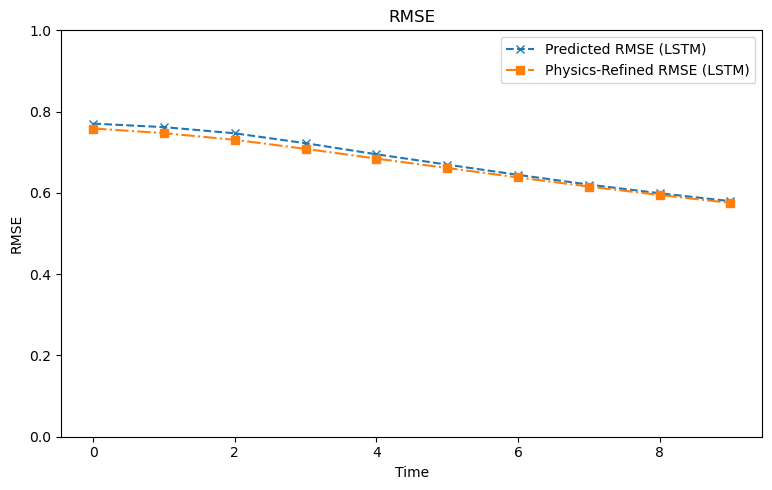

In [8]:
# Compute RMSE at each time step
rmse_lstm_per_t = np.sqrt(np.mean((depth_predictions_np - true_depths_np) ** 2, axis=0))
rmse_phys_per_t = np.sqrt(np.mean((estimated_depth_predictions_np - true_depths_np) ** 2, axis=0))
# Create DataFrame for RMSE values
rmse_df = pd.DataFrame({'rmse_lstm_per_t': rmse_lstm_per_t, 'rmse_phys_per_t': rmse_phys_per_t})
# save to csv
rmse_df.to_csv('LSTM-rmse_values.csv', index=False)
print("RMSE values saved to rmse_values.csv")

# Plot RMSE per timestep
plt.figure(figsize=(8, 5))
plt.plot(
    rmse_lstm_per_t, label="Predicted RMSE (LSTM)", marker="x", linestyle="--"
)
plt.plot(
    rmse_phys_per_t,
    label="Physics-Refined RMSE (LSTM)",
    marker="s",
    linestyle="-.",
)

plt.xlabel("Time")
plt.ylabel("RMSE")
plt.title("RMSE")
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)  # set the ylim 0 to 1
plt.show()
